# 650 nm fixed-focal eye-illumination experiment

## tl;dr

This executed notebook sizes a circular source for 60â€“120 D object-side requirements while holding the retina plane fixed and using only three discrete focal lengths per eye. It does not continuously alter focal length to force focus. The arithmetic is verified within the first-order model, but the real-experiment readiness audit is **NOT READY** because anatomy, real-ray behavior, calibrated radiometry, safety, and ethics evidence are incomplete.

## Context & Methods

- Chick fixed focal lengths: 7.5, 8.0, 8.5 mm.
- Child fixed focal lengths: 13.5, 15.1, 16.7 mm.
- Adult fixed focal lengths: 12.8, 14.75, 16.7 mm.
- The reduced retina distance is the reported axial length divided by 1.336.
- Every row is one eye Ã— focal length Ã— pupil Ã— object distance; no accommodation feasibility test is used.
- The geometric minimum only makes the outer footprint reach the posterior-pole edge. The conservative diameter makes the full-overlap plateau cover the complete posterior-pole disk.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if not (ROOT / 'config' / 'experiment.json').exists():
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'
FIGURES = ROOT / 'figures'
config = json.loads((ROOT / 'config' / 'experiment.json').read_text(encoding='utf-8'))
validation = json.loads((RESULTS / 'validation_report.json').read_text(encoding='utf-8'))
readiness = json.loads((RESULTS / 'real_experiment_readiness.json').read_text(encoding='utf-8'))
config['experiment_id'], validation['overall_status'], readiness['real_experiment_readiness_status']

('eye-illumination-fixed-focal-60-120d-v3', 'passed', 'NOT_READY')

## Data

In [2]:
headline = pd.read_csv(RESULTS / 'headline_results.csv')
fixed = pd.read_csv(RESULTS / 'fixed_focal_source_sweep.csv')
defocus = pd.read_csv(RESULTS / 'defocus_pupil_sweep.csv')
axial = pd.read_csv(RESULTS / 'axial_length_sensitivity.csv')
zos = pd.read_csv(RESULTS / 'zemax' / 'zosapi_validation.csv')
display(headline.head(12))
display(fixed.groupby('eye_id').size().rename('rows'))

,eye_id,eye_label,source_demand_D,source_distance_mm,posterior_pole_diameter_mm,reported_axial_length_mm,image_medium_refractive_index,external_lens_D,sweep_role,fixed_focal_length_mm,...,conservative_plateau_margin_um,pupil_blur_alone_covers_target,maximum_source_pupil_ray_angle_deg,small_angle_linearization_error_percent,working_f_number,paraxial_screening_angle_limit_deg,paraxial_screening_min_f_number,paraxial_screening_pass,model_domain,real_experiment_readiness
0,chick_30_45d,30–45 day chick,60,16.666667,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,0.000000e+00,False,19.176539,3.909256,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
1,chick_30_45d,30–45 day chick,70,14.285714,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,-2.168404e-13,False,20.945735,4.706522,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
2,chick_30_45d,30–45 day chick,80,12.500000,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,2.168404e-13,False,22.674088,5.569421,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
3,chick_30_45d,30–45 day chick,90,11.111111,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,0.000000e+00,False,24.359961,6.495473,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
4,chick_30_45d,30–45 day chick,100,10.000000,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,-2.168404e-13,False,26.002092,7.482154,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
5,chick_30_45d,30–45 day chick,110,9.090909,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,-2.168404e-13,False,27.599569,8.526915,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
6,chick_30_45d,30–45 day chick,120,8.333333,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,7.5,...,2.168404e-13,True,29.151807,9.627210,2.142857,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
7,chick_30_45d,30–45 day chick,60,16.666667,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,8.0,...,0.000000e+00,False,19.918547,4.233318,2.285714,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
8,chick_30_45d,30–45 day chick,70,14.285714,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,8.0,...,0.000000e+00,False,21.670949,5.058228,2.285714,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED
9,chick_30_45d,30–45 day chick,80,12.500000,3,11.7,1.336,0,fixed_focal_object_distance_source_sizing,8.0,...,2.168404e-13,False,23.381778,5.947745,2.285714,10,4,False,FIRST_ORDER_PARAXIAL_ONLY,BLOCKED_CALIBRATION_REQUIRED


eye_id
adult_18y       84
chick_30_45d    84
child_6y        84
Name: rows, dtype: int64

## Fixed focal lengths change the source-size answer

The plotted recommendation is the conservative source diameter at each eye's largest configured pupil. Each panel contains exactly three focal-length curves. The curves differ because object distance, fixed power, pupil blur, and the fixed posterior-pole plane jointly determine the retinal footprint.

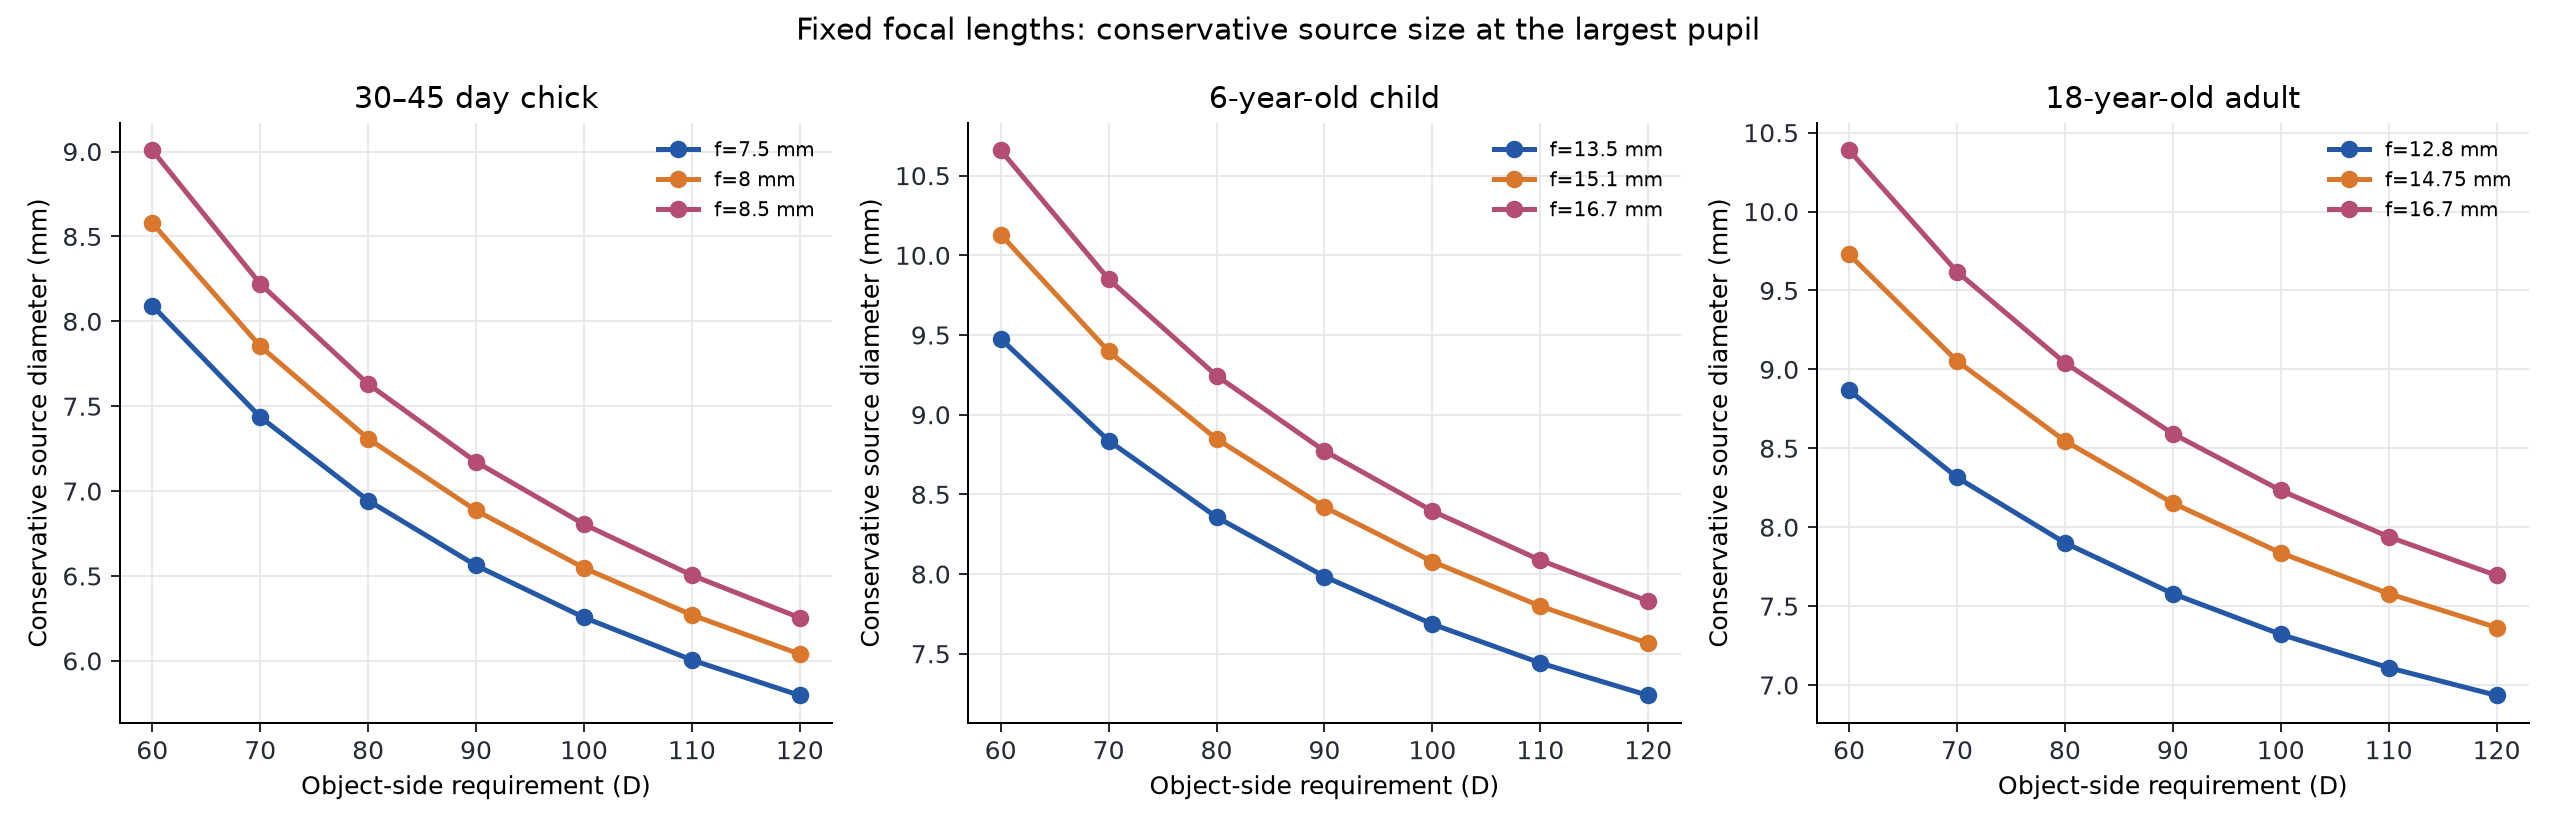

In [3]:
display(Image(filename=str(FIGURES / 'source_diameter_vs_demand.png')))

## Pupil diameter remains an explicit design input

With a fixed focal length the retinal footprint is generally defocused, so pupil diameter is no longer irrelevant. The adult endpoint comparison shows how the recommended conservative source diameter changes with pupil size and the selected fixed focal length.

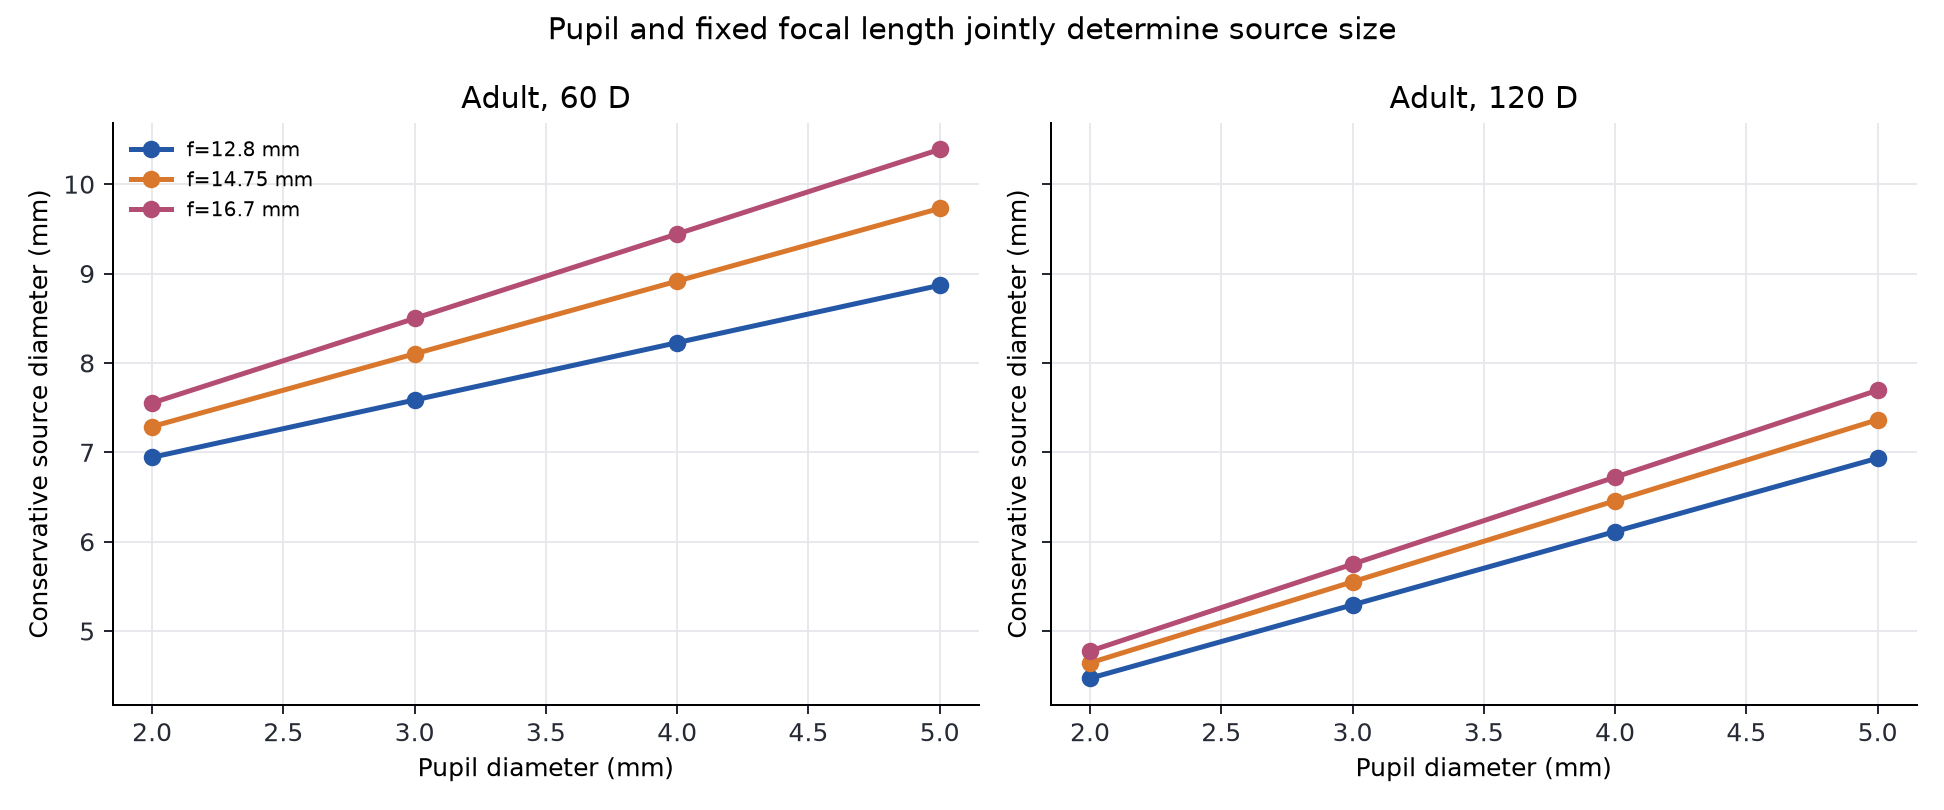

In [4]:
display(Image(filename=str(FIGURES / 'fixed_focal_pupil_comparison.png')))

## Geometric coverage and conservative coverage are different

The geometric minimum can have severe edge roll-off. The conservative full-overlap design is larger but keeps the target inside the convolution plateau. The Monte Carlo maps use 600,000 deterministic rays per case.

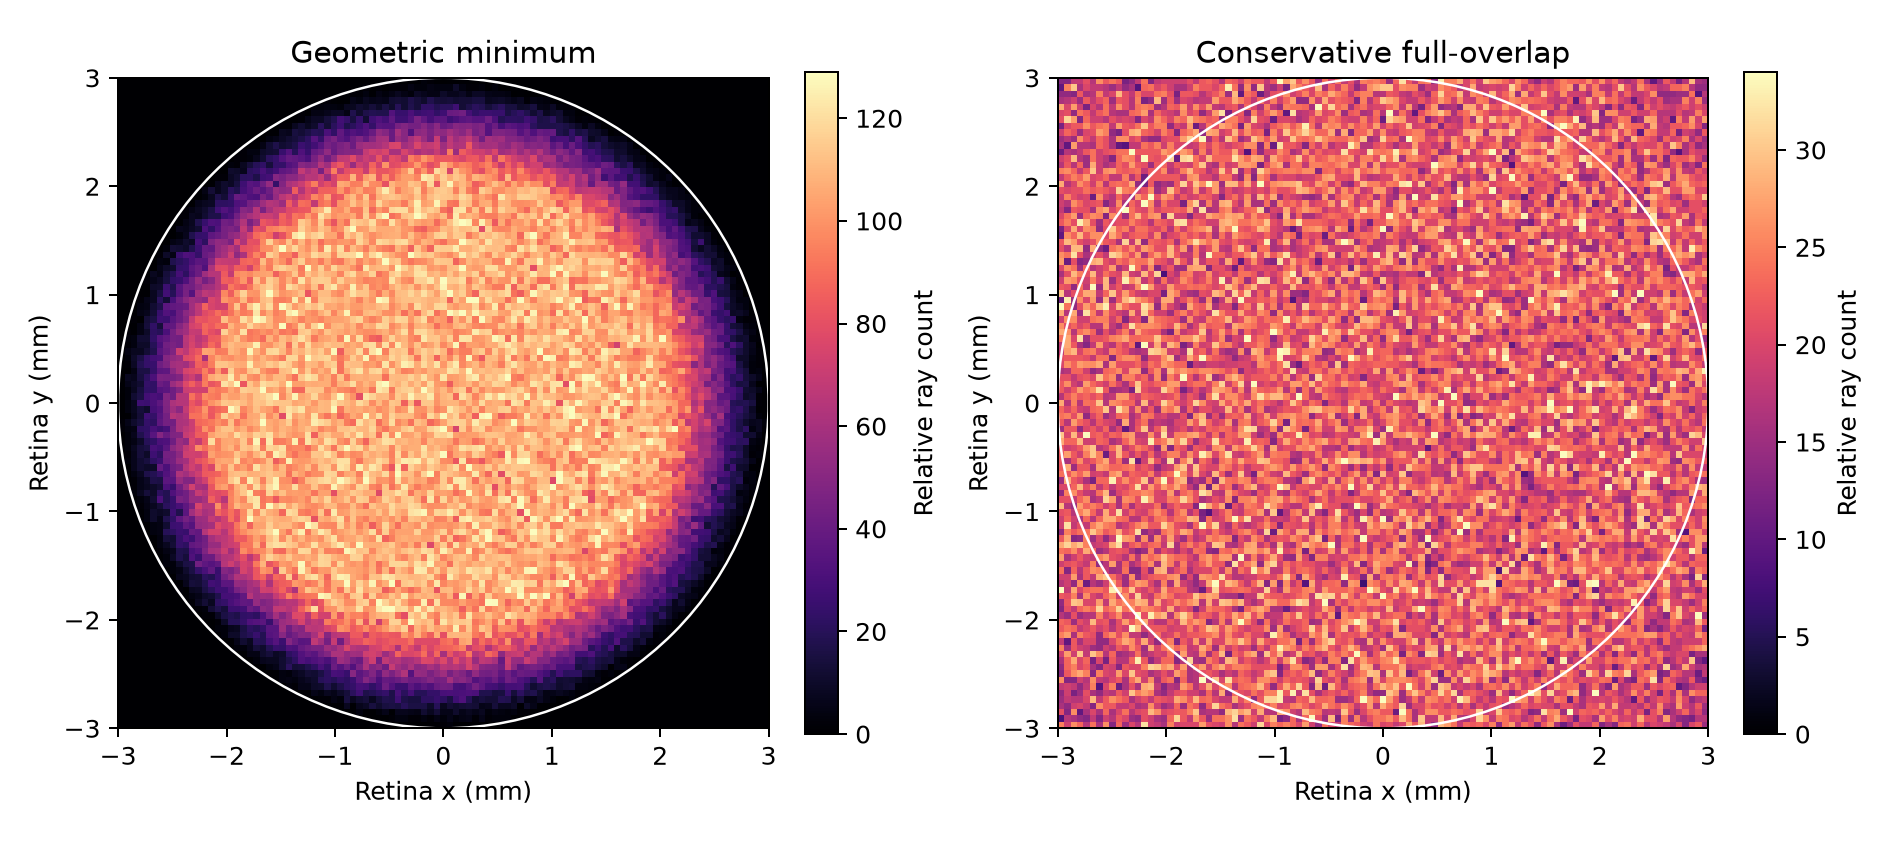

In [5]:
display(Image(filename=str(FIGURES / 'retinal_irradiance_monte_carlo.png')))

## Real OpticStudio cross-validation

Six fixed-focal systems were built through ZOS-API. Four corner rays per system verify the analytical source/pupil footprint bounds at the reduced retina plane.

,case_id,fixed_focal_length_mm,source_distance_mm,pupil_diameter_mm,conservative_source_diameter_mm,bound_error_um
0,chick_fixed_f7p5_d60_p3p5,7.5,16.666667,3.5,8.092593,6.217249e-12
1,chick_fixed_f8p5_d120_p2,8.5,8.333333,2.0,4.797050,1.332268e-12
2,child_fixed_f13p5_d60_p5,13.5,16.666667,5.0,9.476436,2.575717e-11
3,child_fixed_f16p7_d120_p2,16.7,8.333333,2.0,4.874460,1.598721e-11
4,adult_fixed_f12p8_d60_p5,12.8,16.666667,5.0,8.868114,2.309264e-11
5,adult_fixed_f16p7_d120_p2,16.7,8.333333,2.0,4.776007,9.769963e-12


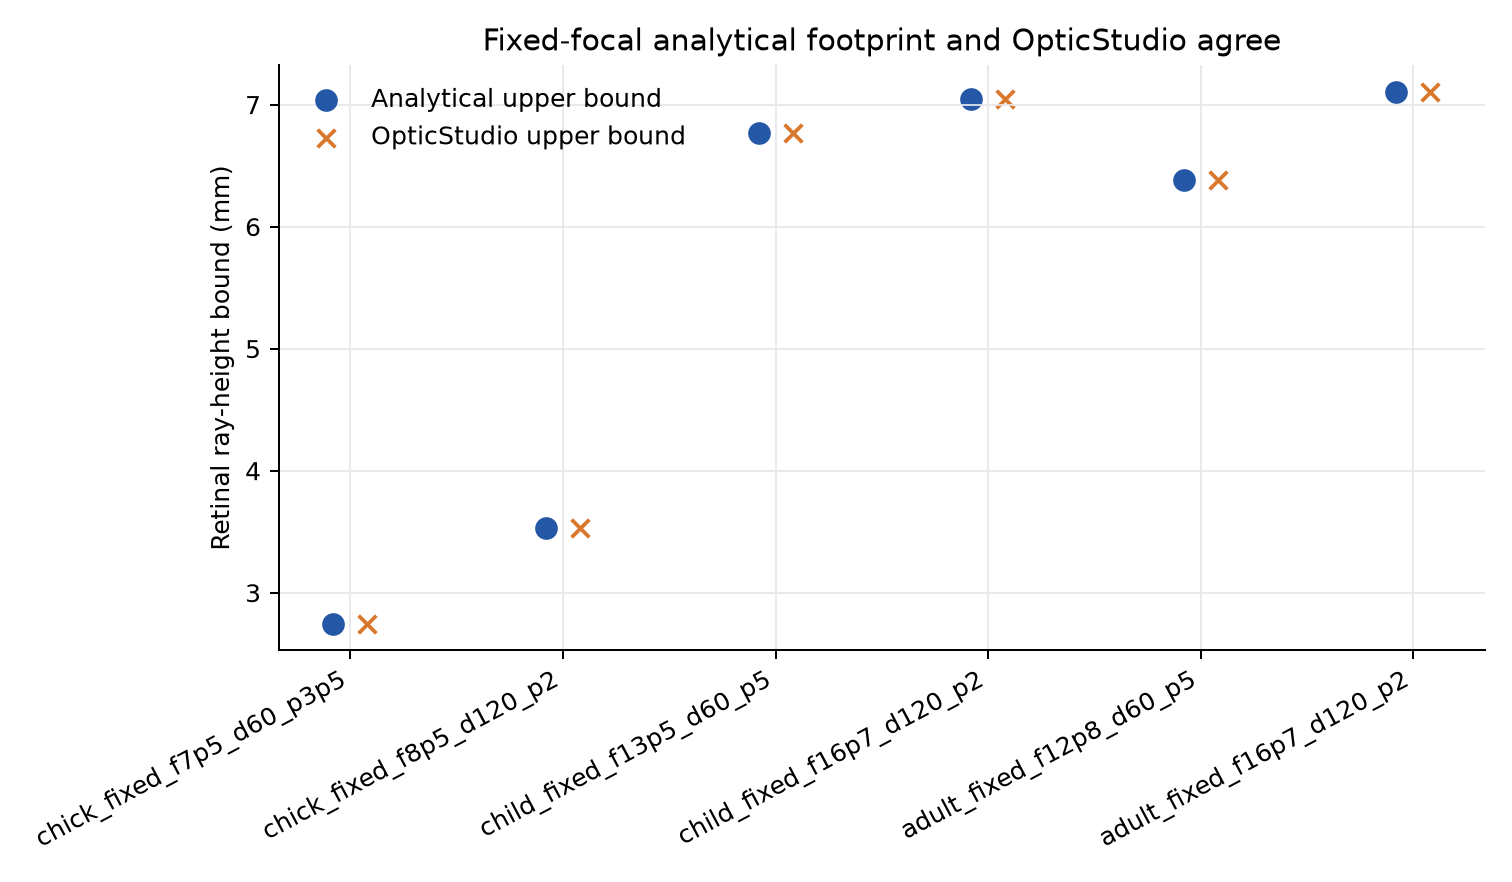

{'fixed_focal_sweep_rows': 252,
 'expected_fixed_focal_sweep_rows': 252,
 'headline_rows': 63,
 'source_demand_levels_D': [60.0, 70.0, 80.0, 90.0, 100.0, 110.0, 120.0],
 'source_demand_step_D': 10.0,
 'fixed_focal_lengths_mm': {'chick_30_45d': [7.5, 8.0, 8.5],
  'child_6y': [13.5, 15.1, 16.7],
  'adult_18y': [12.8, 14.75, 16.7]},
 'expected_fixed_focal_lengths_mm': {'chick_30_45d': [7.5, 8.0, 8.5],
  'child_6y': [13.5, 15.1, 16.7],
  'adult_18y': [12.8, 14.75, 16.7]},
 'contains_accommodation_output': False,
 'all_conservative_sizes_at_least_geometric': True,
 'max_conservative_plateau_residual_um': 1.301042607e-12,
 'min_geometric_coverage_margin_um': 0.0,
 'zos_case_count': 6,
 'zos_system_file_count': 6,
 'zos_bound_max_error_um': 2.5757174171303632e-11,
 'opticstudio_version': '24.1.0',
 'api_license_valid': True,
 'duplicate_case_count': 0,
 'missing_value_count': 0,
 'minimum_maximum_source_pupil_ray_angle_deg': 15.01958967,
 'maximum_maximum_source_pupil_ray_angle_deg': 37.58827

In [6]:
display(zos[['case_id','fixed_focal_length_mm','source_distance_mm','pupil_diameter_mm','conservative_source_diameter_mm','bound_error_um']])
display(Image(filename=str(FIGURES / 'zosapi_cross_validation.png')))
validation

## Real-experiment applicability screen

The OpticStudio evidence above uses an ideal Paraxial surface, so agreement at numerical round-off establishes implementation consistency only. The independent screen recomputes the extreme conservative-source-edge to pupil-edge angle and the working F-number for all 252 cases. Passing a screen would still require an anatomical real-ray model and calibrated bench evidence; failing it blocks promotion of the paraxial value to a physical-eye setting.

In [7]:
applicability = readiness['paraxial_applicability']
display(pd.DataFrame([{
    'cases': applicability['case_count'],
    'minimum edge angle (deg)': applicability['minimum_maximum_ray_angle_deg'],
    'median edge angle (deg)': applicability['median_maximum_ray_angle_deg'],
    'maximum edge angle (deg)': applicability['maximum_maximum_ray_angle_deg'],
    'cases above 10 deg': applicability['cases_above_screening_angle'],
    'cases below F/4': applicability['cases_below_f_number_4'],
    'cases passing both screens': applicability['cases_passing_both_project_screens'],
}]))
readiness['calculation_validation_status'], readiness['decision']

,cases,minimum edge angle (deg),median edge angle (deg),maximum edge angle (deg),cases above 10 deg,cases below F/4,cases passing both screens
0,252,15.01959,22.979718,37.588273,252,140,0


('VERIFIED_WITHIN_FIRST_ORDER_MODEL',
 'DO_NOT_USE_AS_FINAL_EXPOSURE_OR_SAFETY_SETTINGS')

## Takeaways

- The primary matrix contains 252 fixed-focal rows: 3 eyes Ã— 3 focal lengths Ã— 4 pupils Ã— 7 object distances.
- No row changes the assigned focal length to satisfy the object-side requirement.
- The conservative source diameter is a first-order mechanical candidate, not a final experimental or exposure setting.
- Some geometric minima become zero when pupil-driven defocus alone reaches the target; this does not mean a zero-area practical emitter is recommended.
- All 252 cases exceed the project's 10-degree paraxial angle screen; 140 cases are faster than F/4. A measured anatomical real-ray model is required.
- These are paraxial geometric results, not absolute retinal irradiance, biological efficacy, or optical-safety results.